<a href="https://colab.research.google.com/github/pavitoriacosta/data-challenge/blob/master/desafio_looqbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Desafio Looqbox

In [1]:
# Instalando o conector do MySQL
!pip install pymysql sqlalchemy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
from sqlalchemy import create_engine

# Criando a conexão com o banco de dados
USER = "looqbox-challenge"
PASS = "looq-challenge"
HOST = "35.199.115.174"
DATABASE = "looqbox-challenge"

engine = create_engine(f"mysql+pymysql://{USER}:{PASS}@{HOST}/{DATABASE}")

In [4]:
# Teste pra verificar se obtive sucesso na conexão
tabelas = pd.read_sql("SHOW TABLES;", engine)
print("Conexão realizada! essas foram as tabelas encontradas:")
print(tabelas)

Conexão realizada! essas foram as tabelas encontradas:
  Tables_in_looqbox-challenge
0                 IMDB_movies
1                data_product
2          data_product_sales
3              data_store_cad
4            data_store_sales


#Inicio do Teste

###1 - Quais são os 10 produtos mais caros?

Para resolver essa questão, utlizei a tabela data_product. Selecionei o nome e preço do produto, ordenando do maior para o menor (mais caro para o mais barato) e limitei para que me retornassem apenas os dez primeiros.
Dei inicio pela analise exploratória, eu ja havia aberto todas as tabelas acima, mas para melhor organização e visualização, vou deixar as tabelas abertas cada uma na questão em que foi utilizada.

In [9]:
# Análise pré exploratória dos dados

pd.read_sql("DESCRIBE data_product;", engine)

,Field,Type,Null,Key,Default,Extra
0,PRODUCT_COD,int,NO,PRI,None,
1,PRODUCT_NAME,varchar(150),YES,MUL,None,
2,PRODUCT_VAL,"decimal(8,2)",YES,,None,
3,DEP_NAME,varchar(255),YES,,None,
4,DEP_COD,int,YES,,None,
5,SECTION_NAME,varchar(255),YES,,None,
6,SECTION_COD,int,YES,,None,


In [10]:
query_1 = """
SELECT
    PRODUCT_COD,
    PRODUCT_NAME,
    PRODUCT_VAL
FROM data_product
ORDER BY PRODUCT_VAL DESC
LIMIT 10;
"""

In [11]:
df_question_1 = pd.read_sql(query_1, engine)
df_question_1

,PRODUCT_COD,PRODUCT_NAME,PRODUCT_VAL
0,301409,Whisky Escoces THE MACALLAN Ruby Garrafa 700ml...,741.99
1,176185,Whisky Escoces JOHNNIE WALKER Blue Label Garra...,735.90
2,315481,Cafeteira Expresso 3 CORACOES Tres Modo Vermelho,499.00
3,100280,Vinho Portugues Tinto Vintage QUINTA DO CRASTO...,445.90
4,320046,Escova Dental Eletrica ORAL B D34 Professional...,399.90
5,190817,Champagne Rose VEUVE CLICQUOT PONSARDIM Garraf...,366.90
6,153795,Champagne Frances Brut Imperial MOET Rose Garr...,359.90
7,311397,Conjunto de Panelas Allegra em Inox TRAMONTINA...,359.00
8,147706,Whisky Escoces CHIVAS REGAL 18 Anos Garrafa 750ml,329.90
9,154431,Champagne Frances Brut Imperial MOET & CHANDON...,315.90


Na célula acima estão os dez produtos mais caros do estabelecimento.
Algo interessante de se notar é que, em sua maioria, são bebidas alcoolicas importadas.

### 2 - Quais seções os departamentos 'BEBIDAS' e 'PADARIA' possuem?

Novamente, abri a tabela para análise exploratória. Depois, usei a função DISTINCT para que as seções iguais não se repetissem.

In [12]:
# Analise Pré exploratória
pd.read_sql("DESCRIBE data_product;", engine)

,Field,Type,Null,Key,Default,Extra
0,PRODUCT_COD,int,NO,PRI,None,
1,PRODUCT_NAME,varchar(150),YES,MUL,None,
2,PRODUCT_VAL,"decimal(8,2)",YES,,None,
3,DEP_NAME,varchar(255),YES,,None,
4,DEP_COD,int,YES,,None,
5,SECTION_NAME,varchar(255),YES,,None,
6,SECTION_COD,int,YES,,None,


In [14]:
query_2 = """
SELECT DISTINCT
    DEP_NAME AS Departamento,
    SECTION_NAME AS Secao
FROM data_product
WHERE DEP_NAME IN ('BEBIDAS', 'PADARIA')
ORDER BY DEP_NAME, SECTION_NAME;
"""

In [16]:
# Execução

df_question_2 = pd.read_sql(query_2, engine)
df_question_2

,Departamento,Secao
0,BEBIDAS,BEBIDAS
1,BEBIDAS,CERVEJAS
2,BEBIDAS,REFRESCOS
3,BEBIDAS,VINHOS
4,PADARIA,DOCES-E-SOBREMESAS
5,PADARIA,GESTANTE
6,PADARIA,PADARIA
7,PADARIA,QUEIJOS-E-FRIOS


Com isso, é possivel observar que no departamento bebidas temos: cervejas, refrescos e vinhos.
Enquanto no departamento de padaria, temos: doces e sobremesas, padaria e queijo e frios.
Também temos no departamento padaria a seção gestante, algo que deve ser observado.

### 3 - Venda total por Área de Negócio no Q1 de 2019

Comecei pela analise pré exploratória, então abri a tabela de vendas e depois juntei com a de produtos, para obter a business area (separei pelos departamentos como não achei uma coluna com o nome área de negócios).


In [17]:
# Analise exploratória

pd.read_sql("DESCRIBE data_product_sales;", engine)

,Field,Type,Null,Key,Default,Extra
0,STORE_CODE,varchar(255),NO,PRI,None,
1,PRODUCT_CODE,int,NO,PRI,None,
2,DATE,date,NO,PRI,None,
3,SALES_VALUE,"decimal(10,2)",YES,,None,
4,SALES_QTY,"decimal(10,0)",YES,,None,


In [20]:
# Juntando as tabelas

query_3 = """
SELECT
    p.DEP_NAME AS Business_Area,
    SUM(v.SALES_VALUE) AS Venda_Total
FROM data_product_sales v
INNER JOIN data_product p ON v.PRODUCT_CODE = p.PRODUCT_COD
WHERE v.DATE BETWEEN '2019-01-01' AND '2019-03-31'
GROUP BY p.DEP_NAME
ORDER BY Venda_Total DESC;
"""

In [21]:
df_question_3 = pd.read_sql(query_3, engine)
df_question_3

,Business_Area,Venda_Total
0,BEBES,61208448.52
1,PERFUMARIA,51962138.32
2,MERCEARIA,36892430.40
3,MEDICAMENTOS REFERÊNCIA,29797611.84
4,FRIOS,29770139.05
5,PET-SHOP,29206030.00
6,BEBIDAS,28562132.80
7,CARNES,25716171.00
8,FLV,21143030.75
9,MEDICAMENTOS GENÉRICOS,17380394.40


#Python

### Case 1: Criando uma função Python

Nessa parte, criei uma função flexível para puxar os dados de vendas direto do banco. A ideia é conseguir filtrar as informações de um jeito dinâmico usando três parâmetros:

Os parametros escolhidos foram:

- lista de código de produtos
- data de inicio
- data de término
Eu usei a lógica do WHERE 1=1. Assim a função monta a query adicionando os filtros só se eu passar algum valor. Se eu não passar nada, ela traz a tabela inteira de vendas sem quebrar o código.


In [22]:
def buscar_vendas(engine, product_code=None, start_date=None, end_date=None):
    """
    Função dinâmica para buscar e filtrar dados da tabela data_product_sales.
    """
    # 1. Base da query SQL
    query = "SELECT * FROM data_product_sales WHERE 1=1"

    # 2. Se o usuário passou uma lista de produtos, adiciona o filtro na query
    if product_code is not None:
        if isinstance(product_code, list):
            # Transforma a lista [1, 2, 3] em uma string "(1, 2, 3)" para o SQL
            produtos_str = ", ".join(map(str, product_code))
            query += f" AND PRODUCT_CODE IN ({produtos_str})"
        else:
            query += f" AND PRODUCT_CODE = {product_code}"

    if start_date is not None:
        query += f" AND DATE >= '{start_date}'"

    if end_date is not None:
        query += f" AND DATE <= '{end_date}'"

    # Executa a query final combinada e retorna o resultado
    print(f"Executando a query:\n{query}\n")
    df_resultado = pd.read_sql(query, engine)
    return df_resultado

In [23]:
#Testando a função

df_teste_funcao = buscar_vendas(engine, start_date="2019-01-01", end_date="2019-01-10")

df_teste_funcao.head()

Executando a query:
SELECT * FROM data_product_sales WHERE 1=1 AND DATE >= '2019-01-01' AND DATE <= '2019-01-10'



,STORE_CODE,PRODUCT_CODE,DATE,SALES_VALUE,SALES_QTY
0,1,18,2019-01-01,708.5,65.0
1,1,18,2019-01-02,1297.1,119.0
2,1,18,2019-01-03,1144.5,105.0
3,1,18,2019-01-04,1090.0,100.0
4,1,18,2019-01-05,893.8,82.0


### Case 2 - Juntando filtros e Pandas

Aqui eu abri as duas tabelas completas do banco de dados (o cadastro das lojas e as vendas) para fazer os filtros e juntar direto no Python usando o Pandas. O objetivo é cruzar os dados dessas tabelas e filtrar o período do último trimestre de 2019 (de outubro a dezembro).

In [24]:
# 1. Puxando as tabelas completas do banco de dados
df_store_cad = pd.read_sql("SELECT * FROM data_store_cad;", engine)
df_store_sales = pd.read_sql("SELECT * FROM data_store_sales;", engine)

# 2. Filtrando as datas no Pandas (último trimestre de 2019)
# Vendo se o Pandas reconhece a coluna como data
df_store_sales['DATE'] = pd.to_datetime(df_store_sales['DATE'])

# Apliquei o filtro
df_vendas_filtrado = df_store_sales[
    (df_store_sales['DATE'] >= '2019-10-01') &
    (df_store_sales['DATE'] <= '2019-12-31')
]

# 3. Fiz (Merge) das duas tabelas usando Pandas
df_resultado_case2 = pd.merge(df_vendas_filtrado, df_store_cad, on='STORE_CODE', how='inner')

# Abrindo o head para ver o resultado
df_resultado_case2.head()

,STORE_CODE,DATE,SALES_VALUE,SALES_QTY,STORE_NAME,START_DATE,END_DATE,BUSINESS_NAME,BUSINESS_CODE
0,1,2019-10-01,187601.54,12160,Sao Paulo,2006-10-01,,Varejo,1
1,10,2019-10-01,139038.86,5223,Hong Kong,2019-01-01,,Farma,4
2,11,2019-10-01,252687.35,8481,Rio de Janeiro,2019-01-01,,Farma,4
3,12,2019-10-01,223973.64,7659,Madri,2019-01-01,,Farma,4
4,13,2019-10-01,187601.54,12160,Dubai,2019-01-01,,Atacado,5


#Visualização dos dados

Para a última parte do desafio, importei a tabela de filmes do IMDB para fazer uma análise exploratória. Primeiro,  abri e dei uma olhada na estrutura das colunas e depois criei um gráfico de barras para mostrar os gêneros de filmes com as maiores notas médias na plataforma, justificando a escolha desse visual.

In [25]:
# Analise exploratória


df_imdb = pd.read_sql("SELECT * FROM IMDB_movies;", engine)
print(df_imdb.columns.tolist())
df_imdb.head(2)

['Id', 'Title', 'Genre', 'Director', 'Actors', 'Year', 'Runtime', 'Rating', 'Votes', 'RevenueMillions', 'Metascore']


,Id,Title,Genre,Director,Actors,Year,Runtime,Rating,Votes,RevenueMillions,Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.0,757074,333.0,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.0,65.0


Para a primeira visualização, resolvi trazer os 10 diretores que mais faturaram em bilheteria

/tmp/ipykernel_1692/2978286038.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(


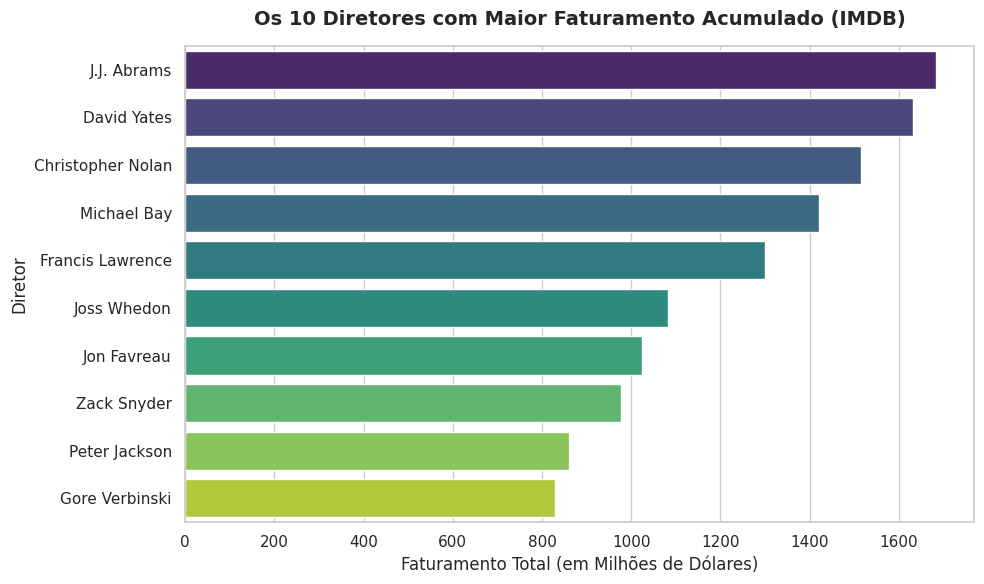

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tratando os dados
df_faturamento_diretor = df_imdb.dropna(subset=['RevenueMillions'])
diretores_top10 = (
    df_faturamento_diretor.groupby('Director')['RevenueMillions']
    .sum()
    .reset_index()
    .sort_values(by='RevenueMillions', ascending=False)
    .head(10)
)

# definindo a configuração dos graficos
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# criando o grafico
grafico = sns.barplot(
    x='RevenueMillions',
    y='Director',
    data=diretores_top10,
    palette='viridis'
)
plt.title('Os 10 Diretores com Maior Faturamento Acumulado (IMDB)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Faturamento Total (em Milhões de Dólares)', fontsize=12)
plt.ylabel('Diretor', fontsize=12)

# abrindo o grafico
plt.tight_layout()
plt.show()

Escolhi criar um gráfico de barras horizontais para cruzar os diretores com o faturamento acumulado dos seus filmes. A escolha do formato horizontal foi baseada na estética e na facilidade na leitura dos nomes dos diretores sem precisar inclinar o texto do eixo. O gráfico mostra de forma bem clara quem são os diretores que mais movem bilheterias na lista do IMDB, destacando os líderes de receita de maneira muito visual e rápida para qualquer pessoa de negócios entender.

Como fiz o jupyter notebook através do google colab, tive auxilio do gemini durante o processo, uma vez que na própria ferramente tem habilitado o uso automatico.
Utilizei em coisas pontuais, como correção de sintaxe etc.